In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Read the dataset
df=pd.read_csv('housing_data.csv')

In [4]:
# View the data

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200,NEAR BAY


In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15,-119.78,36.74,35,2600,470,1450,460,3.9,220000,INLAND
16,-120.99,37.64,28,3300,590,1650,570,4.5,280000,INLAND
17,-122.08,37.39,12,5000,850,2300,800,9.1,600000,NEAR BAY
18,-121.89,37.34,10,4700,810,2200,780,8.7,580000,INLAND
19,-118.15,33.80,22,3000,560,1550,540,5.4,395000,NEAR OCEAN


In [8]:
df.shape

(20, 10)

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20 non-null     float64
 1   latitude            20 non-null     float64
 2   housing_median_age  20 non-null     int64  
 3   total_rooms         20 non-null     int64  
 4   total_bedrooms      20 non-null     int64  
 5   population          20 non-null     int64  
 6   households          20 non-null     int64  
 7   median_income       20 non-null     float64
 8   median_house_value  20 non-null     int64  
 9   ocean_proximity     20 non-null     object 
dtypes: float64(3), int64(6), object(1)
memory usage: 1.7+ KB


In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,-121.140000,36.90500,33.650000,3005.450000,545.550000,1343.150000,525.600000,5.585540,362990.000000
std,1.722193,1.72475,15.284237,1491.324543,248.123372,628.705544,248.528173,2.048227,109501.006484
min,-122.290000,32.72000,10.000000,880.000000,129.000000,322.000000,126.000000,2.080400,220000.000000
25%,-122.252500,37.18250,20.750000,2308.000000,422.500000,961.750000,409.750000,3.886550,277425.000000
50%,-122.150000,37.84000,32.500000,2950.000000,550.000000,1425.000000,527.000000,5.521550,347150.000000
75%,-120.687500,37.85000,52.000000,3512.250000,692.000000,1662.500000,660.250000,7.318050,412500.000000
max,-117.160000,38.58000,52.000000,7099.000000,1106.000000,2401.000000,1138.000000,9.100000,600000.000000


In [11]:
# Checking missing values

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

#**EXPLORATORY DATA ANALYSIS(EDA)**

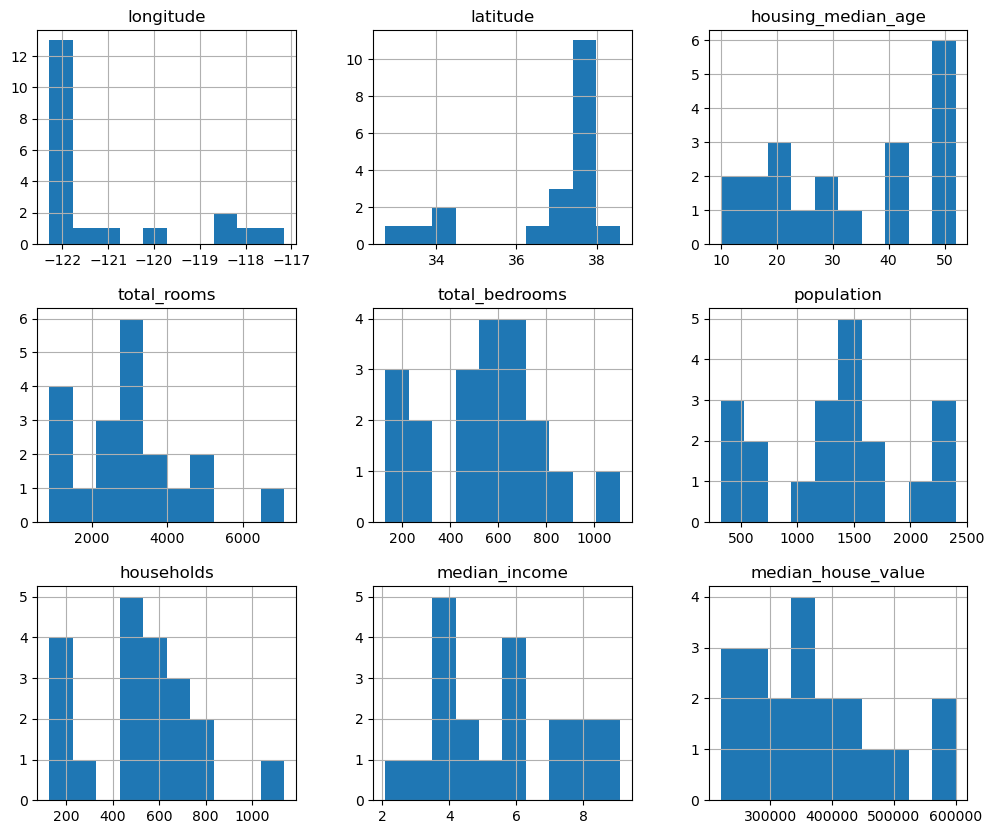

In [13]:
#HISTOGRAM
df.hist(figsize=(12,10))
plt.show()

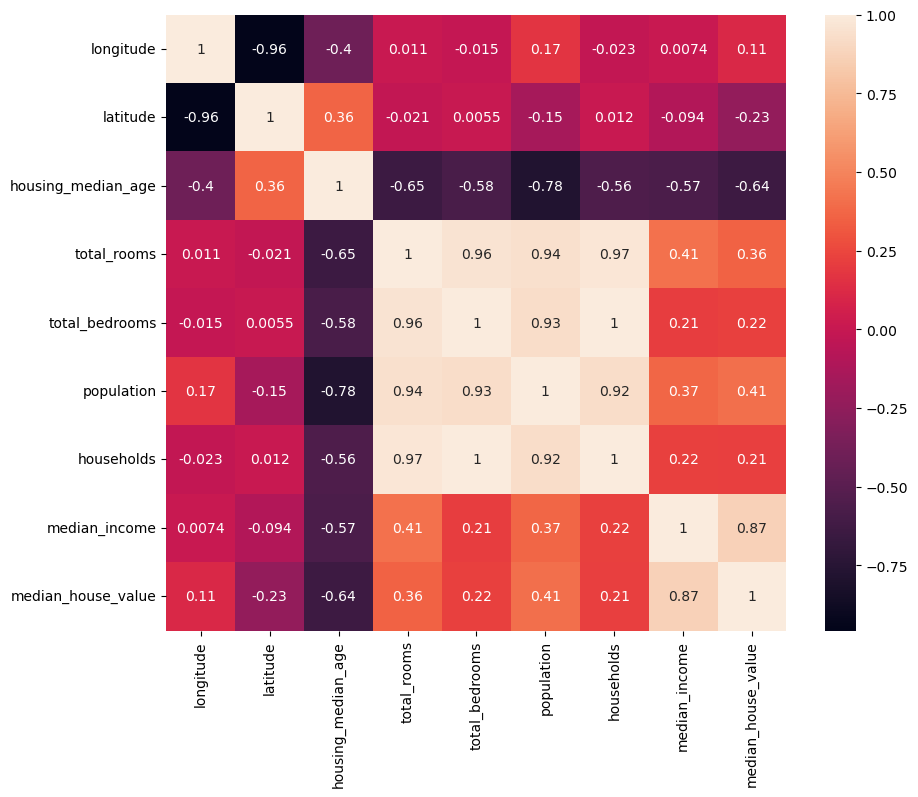

In [14]:
# Correlation Heatmap 

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

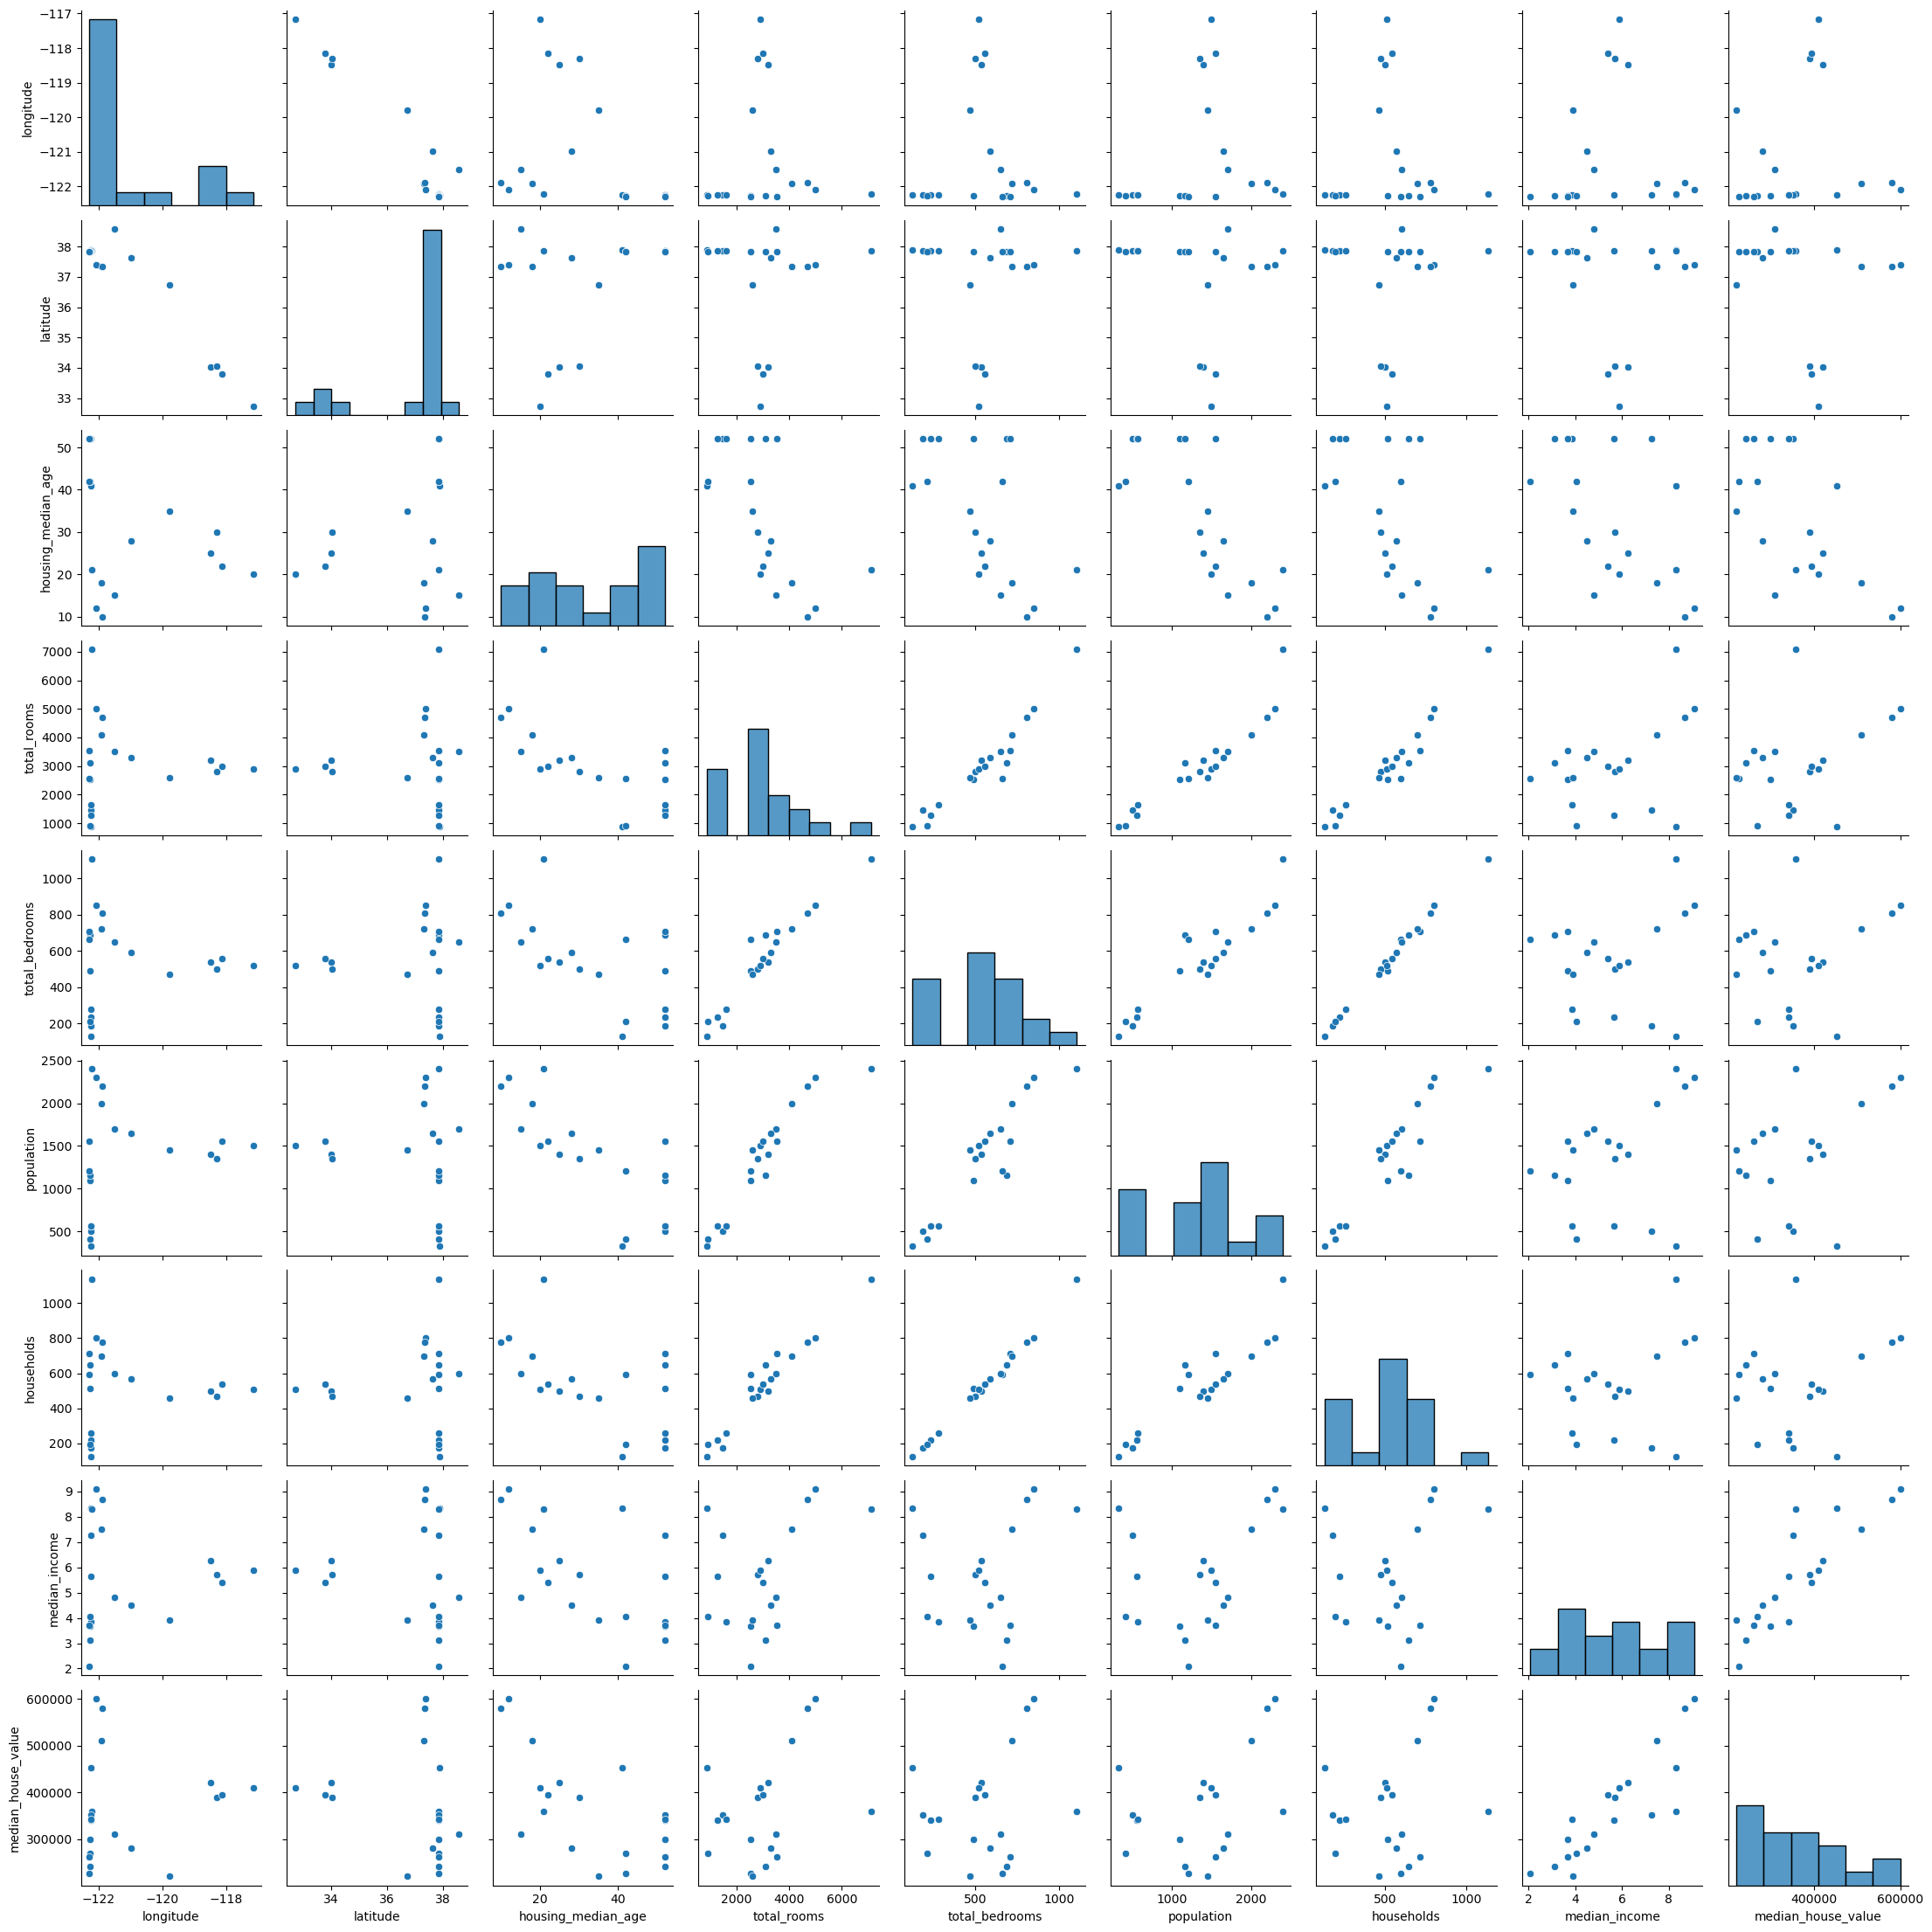

In [16]:
# pairplot

sns.pairplot(df)
plt.show()

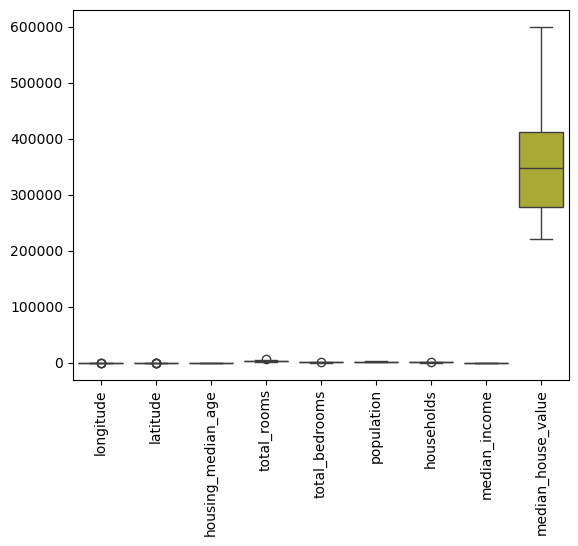

In [19]:
#Boxplot

sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [20]:
# Convert the categorical Data

df=pd.get_dummies(df,columns=['ocean_proximity'],drop_first=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20 non-null     float64
 1   latitude                    20 non-null     float64
 2   housing_median_age          20 non-null     int64  
 3   total_rooms                 20 non-null     int64  
 4   total_bedrooms              20 non-null     int64  
 5   population                  20 non-null     int64  
 6   households                  20 non-null     int64  
 7   median_income               20 non-null     float64
 8   median_house_value          20 non-null     int64  
 9   ocean_proximity_NEAR BAY    20 non-null     bool   
 10  ocean_proximity_NEAR OCEAN  20 non-null     bool   
dtypes: bool(2), float64(3), int64(6)
memory usage: 1.6 KB


In [22]:
# Seprate input and output

X=df.drop("median_house_value",axis=1)
y=df["median_house_value"]

In [26]:
# Split the data
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Train the model

from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

In [30]:
# Presdict
y_pred=model.predict(X_test)

In [31]:
#Evaluate  the model

from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(mse)
print(rmse)
print(r2)

11893776910.060738
109058.59393033058
0.3792975740147748


#**Compare Actual vs PREDICTED**

In [33]:
result=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
result.head()

,Actual,Predicted
0,452600,363124.673084
17,600000,605019.418885
15,220000,212407.028504
1,358500,557211.916430


#**Sctter Plot**

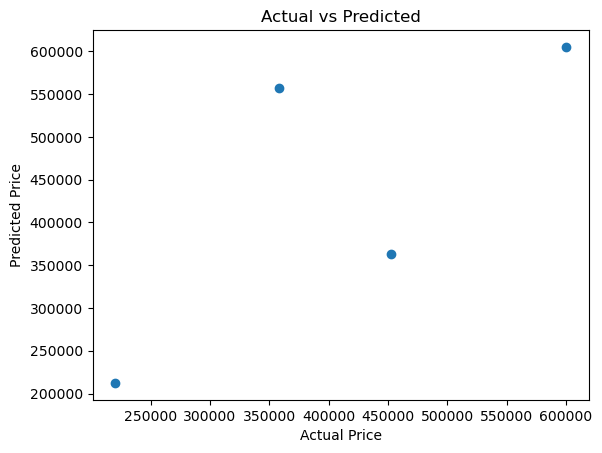

In [35]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# **Conclusion**

"A Linear Regression model was trained to predict median house values. After preprocessing and exploratory data analysis, the model was evaluated using MSE, RMSE, and R² score. The results indicate how effectively the model predicts house prices based on the available features."